In [1]:
# Importing Required Libraries  
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns

# Loading the Dataset 
df=pd.read_csv("Project_Resources/train.csv",index_col="Row_ID")

# Data Cleanup
df=df.convert_dtypes()
df["Postal_Code"]=df["Postal_Code"].fillna(0)
df["Postal_Code"]=df["Postal_Code"].astype(int)
l=["Order_Date","Ship_Date"]
for i in l:
    df[i]=pd.to_datetime(df[i],format="%d-%m-%Y")

# Most contributing state
This Analysis will help us understand our: 
1. Top contributing states on the basis of total revenue generated and no. of products delivered.
2. Also give us an idea of the region our services are mostly used, by our customer. 

In [2]:
df["State"].value_counts().head(10).to_frame()

,count
State,
California,1946
New York,1097
Texas,973
Pennsylvania,582
Washington,504
Illinois,483
Ohio,454
Florida,373
Michigan,253


In [3]:
df_annual=df[df["Order_Date"].dt.year==2017]
df_state=df_annual.groupby("State")["Sales"].agg(["count","sum"]).sort_values(by="count", ascending=False)
df_state=df_state.rename(columns={"count": "No of deliveries made", "sum": "Sales"})
df_state.iloc[:10, :]

,No of deliveries made,Sales
State,,
California,508,126542.9635
New York,311,70826.558
Texas,243,41005.376
Pennsylvania,136,32996.372
Ohio,129,24135.082
Washington,122,19814.284
Illinois,121,21033.719
Florida,84,13528.9635
North Carolina,74,14967.296


In [5]:
df_top_states=df_state.head(10)

`adjust_text()` This function allows us to draw objects in to the graph like in this example this fuction was used to draw leader lines to the labels.

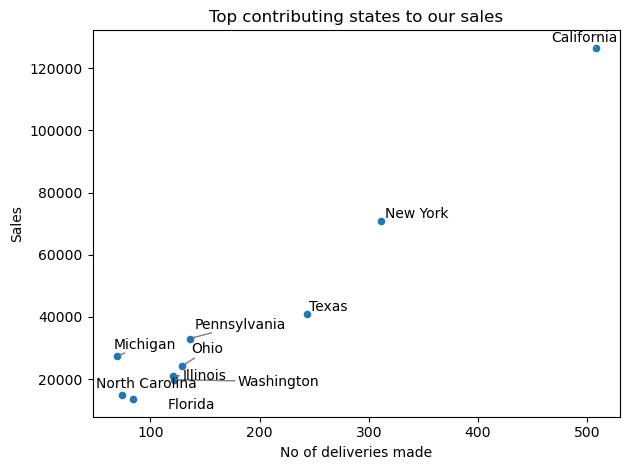

In [6]:
from adjustText import adjust_text
texts=[]
df_top_states.plot(kind="scatter", x="No of deliveries made", y="Sales" )
mp.title("Top contributing states to our sales")
for i, city in enumerate(df_top_states.index):
    texts.append(mp.text( df_top_states["No of deliveries made"].iloc[i], df_top_states["Sales"].iloc[i], city))
adjust_text(texts, arrowprops=dict(arrowstyle="->",color="gray",lw=1))
ax=mp.gca()
mp.tight_layout()
mp.show()

`merge()` This fuction allows us to sort of join two dataframes/tables based on the specified primary key.

In [7]:
df_region=df_annual[["State","Region"]]
df_new=df_region.value_counts().to_frame()
df_new=df_new.reset_index()
df_state=df_state.reset_index()
df_merged=df_state.merge(df_new, on="State")
df_merged=df_merged.drop_duplicates(subset="State")
df_merged.set_index("State", inplace= True)
df_merged.drop(labels="count", axis=1, inplace=True)

In [8]:
df_plot=df_merged.head(10)
df_plot

,No of deliveries made,Sales,Region
State,,,
California,508,126542.9635,West
New York,311,70826.558,East
Texas,243,41005.376,Central
Pennsylvania,136,32996.372,East
Ohio,129,24135.082,East
Washington,122,19814.284,West
Illinois,121,21033.719,Central
Florida,84,13528.9635,South
North Carolina,74,14967.296,South


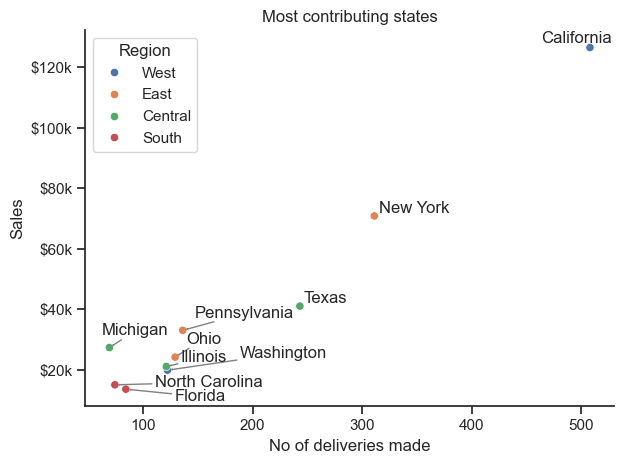

In [14]:
from adjustText import adjust_text
texts=[]
sns.scatterplot(data=df_plot, x="No of deliveries made", y="Sales", hue="Region")
sns.despine()
sns.set_theme(style="ticks")

mp.xlabel("No of deliveries made")
mp.ylabel("Sales")
mp.title("Most contributing states")

for i, state in enumerate(df_plot.index):
    texts.append(mp.text( df_plot["No of deliveries made"].iloc[i], df_plot["Sales"].iloc[i], state))
adjust_text(texts, arrowprops=dict(arrowstyle="->",color="gray"))
ax=mp.gca()
ax.yaxis.set_major_formatter(mp.FuncFormatter(lambda y, pos: f"${int(y/1000)}k"))
mp.tight_layout()
mp.show()